<a href="https://colab.research.google.com/github/MalkRoshdy/Weather-detector-/blob/main/model5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount Google Drive

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load Image Data and Labels

In [13]:
import numpy as np

# Images
X_img_train = np.load('/content/drive/MyDrive/final_data/X_img_train.npy')
X_img_val   = np.load('/content/drive/MyDrive/final_data/X_img_val.npy')
X_img_test  = np.load('/content/drive/MyDrive/final_data/X_img_test.npy')

# Labels
y_train = np.load('/content/drive/MyDrive/final_data/y_train.npy')
y_val   = np.load('/content/drive/MyDrive/final_data/y_val.npy')
y_test  = np.load('/content/drive/MyDrive/final_data/y_test.npy')

# Check Dataset Shapes

In [14]:
print(X_img_train.shape)
print(y_train.shape)

(637, 224, 224, 3)
(637,)


# Check Number of Classes

In [15]:
import numpy as np

print(np.unique(y_train))
print(len(np.unique(y_train)))

[0 1 2 3 4 5]
6


# Load Text Sequences

In [16]:
# Text sequences
X_txt_train = np.load('/content/drive/MyDrive/final_data/X_txt_seq_train.npy')
X_txt_val   = np.load('/content/drive/MyDrive/final_data/X_txt_seq_val.npy')
X_txt_test  = np.load('/content/drive/MyDrive/final_data/X_txt_seq_test.npy')

print(X_txt_train.shape)
print(X_txt_train[0])

(637, 100)
[ 36  11  36   2   4  49  50  30  16  51  37   2   8   5  89  28  20   3
  52  18  90  91  92  93  94  95   3  96  97  18   7  38  39  22  34   9
  23  10  98  18   7  99 100 101 102  12 103  18   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]


# Install Required Libraries

In [17]:
!pip install transformers timm -q

# Import Required Libraries

In [18]:
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from transformers import BertTokenizer, BertModel

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Read JSON File and Convert to DataFrame

In [19]:


with open('/content/drive/MyDrive/image_dataset_scraped.json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)

print(df.head())

                image         drug  \
0   Paracetamol/1.jpg  paracetamol   
1   Paracetamol/2.jpg  paracetamol   
2   Paracetamol/3.jpg  paracetamol   
3  Paracetamol/10.jpg  paracetamol   
4  Paracetamol/11.jpg  paracetamol   

                                                text  
0  paracetamol medicine Paracetamol,[a] or acetam...  
1  paracetamol medicine Paracetamol,[a] or acetam...  
2  paracetamol medicine Paracetamol,[a] or acetam...  
3  paracetamol medicine Paracetamol,[a] or acetam...  
4  paracetamol medicine Paracetamol,[a] or acetam...  


# Convert Drug Names into Numerical Labels

In [20]:
label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(df['drug'])

print(df[['drug', 'label']].head())

          drug  label
0  paracetamol      5
1  paracetamol      5
2  paracetamol      5
3  paracetamol      5
4  paracetamol      5


# Initialize BERT Tokenizer

In [21]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Remove Drug Names from Text (Leakage reduction step)

In [25]:
def clean_text(text):

    drugs = [
        'paracetamol',
        'ibuprofen',
        'amoxicillin',
        'omeprazole',
        'metformin',
        'insulin'
    ]

    text = text.lower()

    for drug in drugs:
        text = text.replace(drug, '')

    return text

# Apply Text Cleaning

In [27]:
df['clean_text'] = df['text'].apply(clean_text)

# Compare Original and Cleaned Text

In [28]:
print(df[['text', 'clean_text']].head())

                                                text  \
0  paracetamol medicine Paracetamol,[a] or acetam...   
1  paracetamol medicine Paracetamol,[a] or acetam...   
2  paracetamol medicine Paracetamol,[a] or acetam...   
3  paracetamol medicine Paracetamol,[a] or acetam...   
4  paracetamol medicine Paracetamol,[a] or acetam...   

                                          clean_text  
0   medicine ,[a] or acetaminophen,[b] is an anal...  
1   medicine ,[a] or acetaminophen,[b] is an anal...  
2   medicine ,[a] or acetaminophen,[b] is an anal...  
3   medicine ,[a] or acetaminophen,[b] is an anal...  
4   medicine ,[a] or acetaminophen,[b] is an anal...  


# Tokenize Cleaned Text Data

In [29]:
MAX_LEN = 100

encoded = tokenizer(
    list(df['clean_text']),
    padding='max_length',
    truncation=True,
    max_length=MAX_LEN,
    return_tensors='pt'
)

input_ids = encoded['input_ids']
attention_mask = encoded['attention_mask']

print(input_ids.shape)

torch.Size([797, 100])


# Prepare Text Data and Labels

In [30]:
from sklearn.model_selection import train_test_split

texts = list(df['clean_text'])
labels = df['label'].values

# Split Text Data into Training and Temporary Sets

In [31]:
txt_train, txt_temp, y_train_txt, y_temp = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

# Split Temporary Data into Validation and Test Sets

In [32]:
txt_val, txt_test, y_val_txt, y_test_txt = train_test_split(
    txt_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Check Dataset Sizes

In [33]:
print(len(txt_train))
print(len(txt_val))
print(len(txt_test))

637
80
80


# Define Text Encoding Function

In [34]:
def encode_texts(texts, tokenizer, max_len=100):

    encoded = tokenizer(
        texts,
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors='pt'
    )

    return encoded['input_ids'], encoded['attention_mask']

# Encode Train, Validation, and Test Text Data

In [35]:
train_input_ids, train_attention_mask = encode_texts(txt_train, tokenizer)

val_input_ids, val_attention_mask = encode_texts(txt_val, tokenizer)

test_input_ids, test_attention_mask = encode_texts(txt_test, tokenizer)

In [36]:
print(train_input_ids.shape)
print(val_input_ids.shape)
print(test_input_ids.shape)

torch.Size([637, 100])
torch.Size([80, 100])
torch.Size([80, 100])


# Import PyTorch and Pretrained Models

In [37]:
import torch
import torch.nn as nn

from torchvision import models
from transformers import BertModel

# Build Multimodal Deep Learning Model using ResNet50 for Image Feature Extraction and BERT for Text Feature Extraction

In [38]:
import torch
import torch.nn as nn

from torchvision import models
from transformers import BertModel


class MultimodalModel(nn.Module):

    def __init__(self, num_classes):

        super(MultimodalModel, self).__init__()


        # =========================
        # IMAGE BRANCH
        # =========================

        self.resnet = models.resnet50(pretrained=True)

        self.resnet.fc = nn.Identity()

        # 2048 → 256
        self.image_fc = nn.Sequential(
            nn.Linear(2048, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )


        # =========================
        # TEXT BRANCH
        # =========================

        self.bert = BertModel.from_pretrained(
            'bert-base-uncased'
        )

        # Freeze أول layers من BERT
        for param in self.bert.parameters():
            param.requires_grad = False

        # 768 → 256
        self.text_fc = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )


        # =========================
        # FUSION
        # =========================

        self.classifier = nn.Sequential(

            nn.Linear(512, 256),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(256, num_classes)
        )


    def forward(self, image, input_ids, attention_mask):


        # =========================
        # IMAGE FEATURES
        # =========================

        image_features = self.resnet(image)

        image_features = self.image_fc(
            image_features
        )


        # =========================
        # TEXT FEATURES
        # =========================

        bert_output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        text_features = bert_output.pooler_output

        text_features = self.text_fc(
            text_features
        )


        # =========================
        # FUSION
        # =========================

        combined = torch.cat(
            (image_features, text_features),
            dim=1
        )

        output = self.classifier(combined)

        return output

# Initialize Multimodal Model

In [39]:
num_classes = 6

model = MultimodalModel(num_classes)

print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MultimodalModel(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
   

# Convert Image Data into PyTorch Tensors

In [40]:
import torch

X_img_train_tensor = torch.tensor(X_img_train).permute(0,3,1,2).float()
X_img_val_tensor   = torch.tensor(X_img_val).permute(0,3,1,2).float()
X_img_test_tensor  = torch.tensor(X_img_test).permute(0,3,1,2).float()

# Normalize Image Tensors

In [41]:
X_img_train_tensor = X_img_train_tensor / 255.0

X_img_val_tensor = X_img_val_tensor / 255.0

X_img_test_tensor = X_img_test_tensor / 255.0

# Convert Labels into Tensors

In [42]:
y_train_tensor = torch.tensor(y_train_txt)
y_val_tensor   = torch.tensor(y_val_txt)
y_test_tensor  = torch.tensor(y_test_txt)

# Build Multimodal Tensor Datasets

In [43]:
from torch.utils.data import TensorDataset, DataLoader

In [44]:
train_dataset = TensorDataset(
    X_img_train_tensor,
    train_input_ids,
    train_attention_mask,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_img_val_tensor,
    val_input_ids,
    val_attention_mask,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_img_test_tensor,
    test_input_ids,
    test_attention_mask,
    y_test_tensor
)

# Create DataLoaders

In [45]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=8)

test_loader = DataLoader(test_dataset, batch_size=8)

# Configure Device and Load Multimodal Model

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultimodalModel(num_classes)

model = model.to(device)
print(device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


cuda


# Define Loss Function and Optimizer

In [47]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

# Train and Evaluate the Multimodal Model

In [48]:
from tqdm import tqdm

EPOCHS = 5

train_losses = []
val_losses = []

for epoch in range(EPOCHS):

    # =========================
    # TRAIN
    # =========================

    model.train()

    total_train_loss = 0


    for batch in tqdm(train_loader):

        images, input_ids, attention_mask, labels = batch

        images = images.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)
        labels = labels.to(device)


        optimizer.zero_grad()


        outputs = model(
            images,
            input_ids,
            attention_mask
        )


        loss = criterion(outputs, labels)


        loss.backward()

        optimizer.step()


        total_train_loss += loss.item()


    avg_train_loss = total_train_loss / len(train_loader)

    train_losses.append(avg_train_loss)


    # =========================
    # VALIDATION
    # =========================

    model.eval()

    total_val_loss = 0


    with torch.no_grad():

        for batch in val_loader:

            images, input_ids, attention_mask, labels = batch

            images = images.to(device)
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)
            labels = labels.to(device)


            outputs = model(
                images,
                input_ids,
                attention_mask
            )


            loss = criterion(outputs, labels)

            total_val_loss += loss.item()


    avg_val_loss = total_val_loss / len(val_loader)

    val_losses.append(avg_val_loss)


    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}")

100%|██████████| 80/80 [00:12<00:00,  6.36it/s]



Epoch 1/5
Train Loss: 1.7449
Val Loss: 1.5997


100%|██████████| 80/80 [00:10<00:00,  7.38it/s]



Epoch 2/5
Train Loss: 1.4889
Val Loss: 1.3150


100%|██████████| 80/80 [00:11<00:00,  7.24it/s]



Epoch 3/5
Train Loss: 1.2412
Val Loss: 1.0107


100%|██████████| 80/80 [00:11<00:00,  7.07it/s]



Epoch 4/5
Train Loss: 1.0122
Val Loss: 0.7937


100%|██████████| 80/80 [00:11<00:00,  6.87it/s]



Epoch 5/5
Train Loss: 0.8398
Val Loss: 0.7578


In [49]:
from sklearn.metrics import accuracy_score, classification_report

# Import Evaluation Metrics

In [50]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for batch in test_loader:

        images, input_ids, attention_mask, labels = batch

        images = images.to(device)
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)


        outputs = model(
            images,
            input_ids,
            attention_mask
        )


        preds = torch.argmax(outputs, dim=1)


        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Calculate Test Accuracy

In [51]:
accuracy = accuracy_score(all_labels, all_preds)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.7375


# Generate Classification Report

In [52]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.80      0.94      0.86        17
           1       1.00      0.46      0.63        13
           2       0.92      0.86      0.89        14
           3       1.00      1.00      1.00         8
           4       1.00      0.36      0.53        14
           5       0.43      0.86      0.57        14

    accuracy                           0.74        80
   macro avg       0.86      0.75      0.75        80
weighted avg       0.84      0.74      0.73        80



# Test Model Prediction on a Single Sample

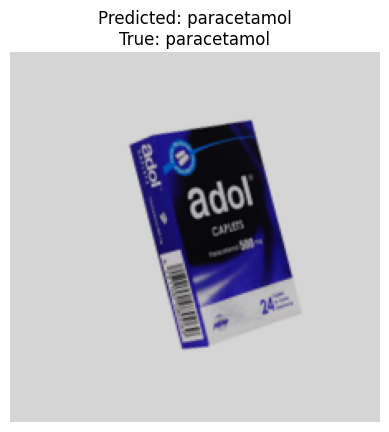


TEXT:

 medicine ,[a] or acetaminophen,[b] is an analgesic and antipyretic agent used to treat fever and mild to moderate pain.[14][15] it is a widely available over-the-counter drug sold generically or under various brand names, including tylenol and panadol.


In [57]:
import matplotlib.pyplot as plt

idx = 60



# =========================
# Prediction
# =========================

model.eval()

image = X_img_test_tensor[idx].unsqueeze(0).to(device)

input_id = test_input_ids[idx].unsqueeze(0).to(device)

attention = test_attention_mask[idx].unsqueeze(0).to(device)

with torch.no_grad():

    output = model(
        image,
        input_id,
        attention
    )

    pred = torch.argmax(output, dim=1).item()


# =========================
# Decode labels
# =========================

predicted_drug = label_encoder.inverse_transform([pred])[0]

true_drug = label_encoder.inverse_transform(
    [y_test_tensor[idx].item()]
)[0]


# =========================
# Show image
# =========================

img = X_img_test[idx]

plt.imshow(img)
plt.axis('off')

plt.title(f"Predicted: {predicted_drug}\nTrue: {true_drug}")

plt.show()


# =========================
# Show text
# =========================

print("\nTEXT:\n")

print(txt_test[idx])

# Recommendation System Integration

This section loads the safety and interaction datasets in JSON format.  
These datasets are used to provide medical recommendations, safety checks, and drug interaction information after the multimodal model predicts the drug class.

In [63]:
from google.colab import files

uploaded = files.upload()

Saving interaction_dataset.json to interaction_dataset (1).json
Saving safety_dataset.json to safety_dataset.json


In [65]:
import json

with open('safety_dataset.json', 'r') as f:
    safety_data = json.load(f)

with open('interaction_dataset.json', 'r') as f:
    interaction_data = json.load(f)

# Safety Recommendation Function

This function checks whether the predicted drug is safe for a specific medical condition and returns the corresponding recommendation and alternative medicine.

In [66]:
def check_safety(drug, condition):

    for item in safety_data:

        if drug.lower() in item['input'] and condition.lower() in item['input']:

            return item['output']

    return "No recommendation found"

# Drug Interaction Function

This function checks possible interactions between drugs using the interaction dataset and returns warning information when necessary.

In [67]:
def check_interaction(drug1, drug2):

    for item in interaction_data:

        if drug1.lower() in item['input'] and drug2.lower() in item['input']:

            return item['output']

    return "No interaction data found"

In [68]:
result = check_safety(
    "ibuprofen",
    "stomach ulcer"
)

print(result)

safety: dangerous; recommendation: do not use; alternative: paracetamol


In [69]:
result = check_interaction(
    "ibuprofen",
    "aspirin"
)

print(result)

safety: dangerous; recommendation: do not combine; alternative: paracetamol


In [70]:
predicted_drug = predicted_drug

condition = "fever"

result = check_safety(
    predicted_drug,
    condition
)

print(result)

safety: safe; recommendation: reduces temperature; alternative: ibuprofen


# full sys with model


In [74]:
import matplotlib.pyplot as plt
import torch


def smart_test_prediction(idx, condition):

    # =========================
    # Get sample
    # =========================

    image = X_img_test_tensor[idx].unsqueeze(0).to(device)

    input_id = test_input_ids[idx].unsqueeze(0).to(device)

    attention = test_attention_mask[idx].unsqueeze(0).to(device)


    # =========================
    # Prediction
    # =========================

    model.eval()

    with torch.no_grad():

        output = model(
            image,
            input_id,
            attention
        )

        pred = torch.argmax(output, dim=1).item()


    # =========================
    # Decode labels
    # =========================

    predicted_drug = label_encoder.inverse_transform([pred])[0]

    true_drug = label_encoder.inverse_transform(
        [y_test_tensor[idx].item()]
    )[0]


    # =========================
    # Recommendation
    # =========================

    recommendation = check_safety(
        predicted_drug,
        condition
    )


    # =========================
    # Show image
    # =========================

    img = X_img_test[idx]

    plt.figure(figsize=(5,5))

    plt.imshow(img)

    plt.axis('off')

    plt.title(
        f"Predicted: {predicted_drug}\nTrue: {true_drug}"
    )

    plt.show()


    # =========================
    # Show recommendation
    # =========================

    print("Condition:", condition)

    print("\nRecommendation:\n")

    print(recommendation)

# to make sure the wrong predict isn't from the missmatch between labels and photos


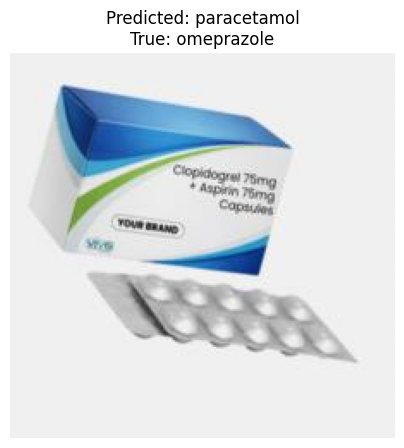

Condition: fever

Recommendation:

safety: safe; recommendation: reduces temperature; alternative: ibuprofen


In [75]:
smart_test_prediction(
    10,
    "fever"
)

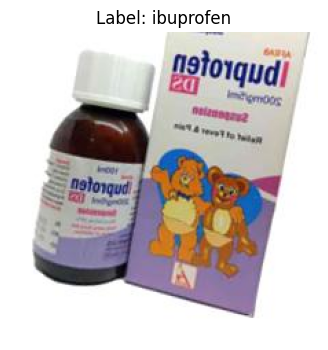

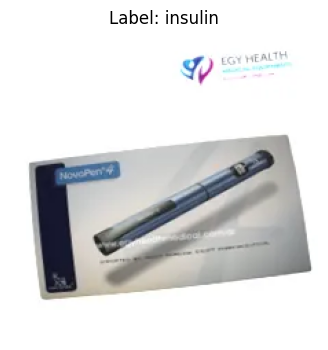

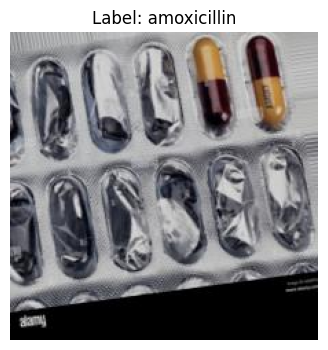

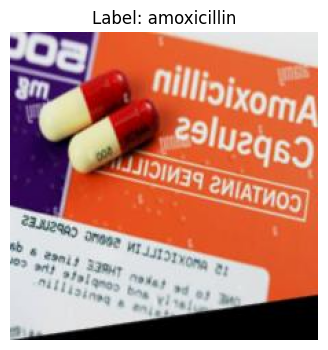

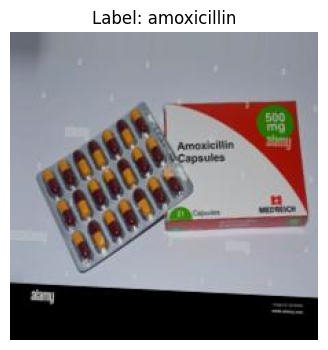

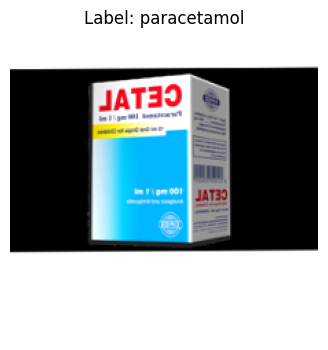

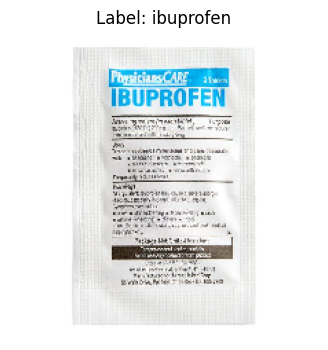

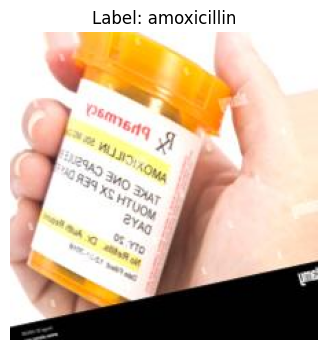

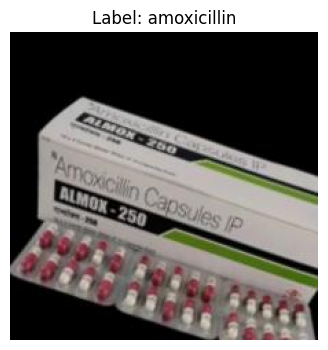

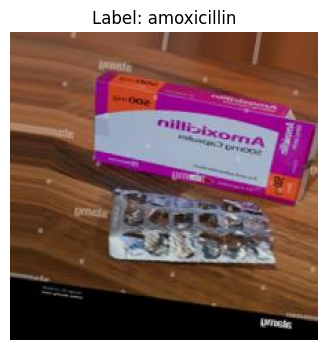

In [76]:
import matplotlib.pyplot as plt

for i in range(10):

    plt.figure(figsize=(4,4))

    plt.imshow(X_img_train[i])

    plt.axis('off')

    label = label_encoder.inverse_transform(
        [y_train[i]]
    )[0]

    plt.title(f"Label: {label}")

    plt.show()

# Saving The Multimodal Medical System

In [77]:
import torch
import joblib


# =========================
# SAVE MODEL
# =========================

torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/multimodal_medical_model.pth"
)


# =========================
# SAVE LABEL ENCODER
# =========================

joblib.dump(
    label_encoder,
    "/content/drive/MyDrive/label_encoder.pkl"
)


# =========================
# SAVE TOKENIZER
# =========================

tokenizer.save_pretrained(
    "/content/drive/MyDrive/bert_tokenizer"
)


print("System Saved Successfully!")

System Saved Successfully!
